# **1/f noise and long-term memory of coherent structures in turbulent RB convection**

- Probability density function of the observable quantities $P(\alpha_k)$

- Frequency power spectra $S(f)$
    $$ S(f) \equiv \vert \hat{X}(f) \vert^2 $$ 
  
  (In practice, we use Welch's method which splits the signal in segments of lenght `nperseg` with 50\% overlap)
  
- Distribution of the waiting time between successive reversals $P(\tau)$

- Exponent $\alpha$ as function of $\beta$

## Preamble

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
pd.set_option('display.max_rows',10)

params = {'backend': 'ps',
          'axes.labelsize': 16,
          'font.size': 16,
          'legend.fontsize': 16,          
          'font.size': 16,          
          'xtick.labelsize': 12,
          'ytick.labelsize': 12,
          'text.usetex': True,
          'font.family': 'serif',
          'figure.figsize': (12, 8),
          'contour.negative_linestyle':'dashed'}
plt.rcParams.update(params)

### 1. Load the observable quantities
In this case, we use the POD modal amplitudes $\alpha_k(t)$, a global measurement, instead of the local velocity as done in other works. 

In [2]:
filename_modes_pr43   = './data_from_dns/modal_50000000_4.3_512_060to259.h5'
filename_modes_pr3   = './data_from_dns/modal_50000000_3_512_016to186.h5'

pod_pr3 = pd.read_hdf(filename_modes_pr3)
n=pod_pr3.shape[0]
t = np.arange(n)/20.
pod_pr3['t'] = t

pod_pr43 = pd.read_hdf(filename_modes_pr43)
n=pod_pr43.shape[0]
t = np.arange(n)/20.
pod_pr43['t'] = t

temp1 = pod_pr43.k3
temp2 = pod_pr43.k4

pod_pr43.k3 = temp2
pod_pr43.k4 = temp1

In [3]:
columns   = ['t','k1','k2','k3','k4','k5','k6','k7','k8','k9','k10','k11','k12']
pod_pr3_ra1e7 = pd.read_csv('./data_from_dns/pr3/proj-coefficients0-F-1e8.asc',sep='\s+',names=columns)
n=pod_pr3_ra1e7.shape[0]
t = np.arange(n)*1.25
pod_pr3_ra1e7['t'] = t

In [4]:
filename_modes_pr43   = './data_from_dns/modal_200000000_4.3_1024_018to046.h5'
pod_pr43_ra2e8 = pd.read_hdf(filename_modes_pr43)
n=pod_pr43_ra2e8.shape[0]
t = np.arange(n)/20.
pod_pr43_ra2e8['t'] = t

### 2. Measure the injection scale $f_0$ related to the large eddy turnover time

In [5]:
reload=False
if reload :
    glb = pd.read_csv('./data_from_dns/global_50000000_3_512_016to186.asc', sep='\\s+', header=0, usecols=[0,1,2,5,6,7,9,10,12,13,14], names=['t','l2d','ekin','phiy','epot','bpot','phid','etmp','m2d','ia2d','ib2d'])
    glb.to_hdf('./data_from_dns/global_50000000_3_512_016to186.h5', '/glb', table=True, mode='w', compression='blosc:lz4', complevel=9, fletcher32=True)

    glb = pd.read_csv('./data_from_dns/global_50000000_4.3_512_060to259.asc', sep='\\s+', header=0, usecols=[0,1,2,5,6,7,9,10,12,13,14], names=['t','l2d','ekin','phiy','epot','bpot','phid','etmp','m2d','ia2d','ib2d'])
    glb.to_hdf('./data_from_dns/global_50000000_4.3_512_060to259.h5', '/glb', table=True, mode='w', compression='blosc:lz4', complevel=9, fletcher32=True)

In [6]:
filename_glb_pr43   = './data_from_dns/global_50000000_4.3_512_060to259.h5'
filename_glb_pr3   = './data_from_dns/global_50000000_3_512_016to186.h5'

glb_pr43 = pd.read_hdf(filename_glb_pr43)
glb_pr3 = pd.read_hdf(filename_glb_pr3)

print("Injection scale for $Ra=5e7, Pr=3.0$ is $f_0 = {0:3.3g}$".format(np.mean(np.sqrt(2.*glb_pr3.ekin.values))))
print("Injection scale for $Ra=5e7, Pr=4.3$ is $f_0 = {0:3.3g}$".format(np.mean(np.sqrt(2.*glb_pr43.ekin.values))))

Injection scale for $Ra=5e7, Pr=3.0$ is $f_0 = 0.289$
Injection scale for $Ra=5e7, Pr=4.3$ is $f_0 = 0.288$


### 3. Compute the spectral densities
We focus on the range between the mean waiting time between successive flow reversals and the eddy turnover time and estimate the scaling exponent $S(f) \sim f^{-\alpha}$

In [7]:
f0 = 0.289

from scipy import signal
nperseg=20000
fsampling=0.05
fsampling2=1.25
welch_pod_pr3 = pd.DataFrame(columns=['f', 'k1', 'k2', 'k3', 'k4', 'k5', 'k6'])
welch_sign_pr3 = pd.DataFrame(columns=['f', 'k1', 'k2', 'k3', 'k4', 'k5', 'k6'])

welch_pod_pr3_ra1e7 = pd.DataFrame(columns=['f', 'k1', 'k2', 'k3', 'k4', 'k5', 'k6'])
welch_sign_pr3_ra1e7 = pd.DataFrame(columns=['f', 'k1', 'k2', 'k3', 'k4', 'k5', 'k6'])


n = pod_pr3['k1'].values.size
m = int(n/2)
for k in ['k1', 'k2', 'k3', 'k4', 'k5', 'k6']:    
    welch_pod_pr3.f, welch_pod_pr3[k] = signal.welch(pod_pr3[k].values, 1./fsampling, nperseg=nperseg, scaling='density')
    welch_sign_pr3.f, welch_sign_pr3[k] = signal.welch(np.sign(pod_pr3[k].values), 1./fsampling, nperseg=nperseg, scaling='density')

    welch_pod_pr3_ra1e7.f, welch_pod_pr3_ra1e7[k] = signal.welch(pod_pr3_ra1e7[k].values, 1./fsampling2, nperseg=nperseg/20, scaling='density')
    welch_sign_pr3_ra1e7.f, welch_sign_pr3_ra1e7[k] = signal.welch(np.sign(pod_pr3_ra1e7[k].values), 1./fsampling2, nperseg=nperseg/20, scaling='density')
    
    
f1 = 1/74.9
#f1 = 1/65.0
welch_pod_pr3_roi = welch_pod_pr3.loc[np.logical_and(welch_pod_pr3.f < f0, welch_pod_pr3.f > f1)]    
welch_pod_pr3_roi2 = welch_pod_pr3.loc[welch_pod_pr3.f > 1.5*f0]    

welch_sign_pr3_roi  = welch_sign_pr3.loc[np.logical_and(welch_sign_pr3.f < f0, welch_sign_pr3.f > f1)]    
welch_sign_pr3_roi2 = welch_sign_pr3.loc[welch_sign_pr3.f > 1.5*f0]    


/home/andres/miniconda3/envs/housecleaning_ac/lib/python3.7/site-packages/scipy/signal/spectral.py:1773: UserWarning: nperseg = 1000 is greater than input length  = 940, using nperseg = 940
  .format(nperseg, input_length))


In [8]:
welch_pod_pr43 = pd.DataFrame(columns=['f', 'k1', 'k2', 'k3', 'k4', 'k5', 'k6'])
welch_sign_pr43 = pd.DataFrame(columns=['f', 'k1', 'k2', 'k3', 'k4', 'k5', 'k6'])

welch_pod_pr43_ra2e8 = pd.DataFrame(columns=['f', 'k1', 'k2', 'k3', 'k4', 'k5', 'k6'])
welch_sign_pr43_ra2e8 = pd.DataFrame(columns=['f', 'k1', 'k2', 'k3', 'k4', 'k5', 'k6'])

n = pod_pr43['k1'].values.size
m = int(n/2)
for k in ['k1', 'k2', 'k3', 'k4', 'k5', 'k6']:    
    welch_pod_pr43.f, welch_pod_pr43[k] = signal.welch(pod_pr43[k].values, 1./fsampling, nperseg=nperseg, scaling='density')
    welch_sign_pr43.f, welch_sign_pr43[k] = signal.welch(np.sign(pod_pr43[k].values), 1./fsampling, nperseg=nperseg, scaling='density')

    welch_pod_pr43_ra2e8.f, welch_pod_pr43_ra2e8[k] = signal.welch(pod_pr43_ra2e8[k].values, 1./fsampling, nperseg=nperseg/5, scaling='density')
    welch_sign_pr43_ra2e8.f, welch_sign_pr43_ra2e8[k] = signal.welch(np.sign(pod_pr43_ra2e8[k].values), 1./fsampling, nperseg=nperseg/5, scaling='density')
    
    
f1 = 1/119.2
#f1 = 1/75.0
welch_pod_pr43_roi = welch_pod_pr43.loc[np.logical_and(welch_pod_pr43.f < f0, welch_pod_pr43.f > f1)]    
welch_pod_pr43_roi2 = welch_pod_pr43.loc[welch_pod_pr43.f > 1.5*f0]    

welch_sign_pr43_roi = welch_sign_pr43.loc[np.logical_and(welch_sign_pr43.f < f0, welch_sign_pr43.f > f1)]    
welch_sign_pr43_roi2 = welch_sign_pr43.loc[welch_sign_pr43.f > 1.5*f0]    


In [9]:
from scipy.optimize import curve_fit
def func(x, a, b):
    return a * np.power(x, -b) 

class exponents:
    pass

alpha_pod_pr3 = exponents()
gamma_pod_pr3 = exponents()

alpha_sign_pr3 = exponents()
gamma_sign_pr3 = exponents()

Alpha_pod_pr3 = pd.DataFrame(columns=['f', 'k1', 'k2', 'k3', 'k4', 'k5', 'k6'])
Gamma_pod_pr3 = pd.DataFrame(columns=['f', 'k1', 'k2', 'k3', 'k4', 'k5', 'k6'])

Alpha_sign_pr3 = pd.DataFrame(columns=['f', 'k1', 'k2', 'k3', 'k4', 'k5', 'k6'])
Gamma_sign_pr3 = pd.DataFrame(columns=['f', 'k1', 'k2', 'k3', 'k4', 'k5', 'k6'])

for k in ['k1', 'k2', 'k3', 'k4', 'k5', 'k6']:    
    # Fit between 1/<tau> and f0
    popt, pcov = curve_fit(func, welch_pod_pr3_roi.f.values, welch_pod_pr3_roi[k].values)    
    setattr(alpha_pod_pr3, k, popt[1])

    Alpha_pod_pr3.f = welch_pod_pr3_roi.f
    Alpha_pod_pr3[k] = func(Alpha_pod_pr3.f, popt[0], popt[1])

    popt, pcov = curve_fit(func, welch_sign_pr3_roi.f.values, welch_sign_pr3_roi[k].values)    
    setattr(alpha_sign_pr3, k, popt[1])

    Alpha_sign_pr3.f = welch_sign_pr3_roi.f
    Alpha_sign_pr3[k] = func(Alpha_sign_pr3.f, popt[0], popt[1])
  
    
    # Fit below f0
    popt, pcov = curve_fit(func, welch_pod_pr3_roi2.f.values, welch_pod_pr3_roi2[k].values)    
    setattr(gamma_pod_pr3, k, popt[1])

    Gamma_pod_pr3.f = welch_pod_pr3_roi2.f
    Gamma_pod_pr3[k] = func(Gamma_pod_pr3.f, popt[0], popt[1])
    
    popt, pcov = curve_fit(func, welch_sign_pr3_roi2.f.values, welch_sign_pr3_roi2[k].values)    
    setattr(gamma_sign_pr3, k, popt[1])

    Gamma_sign_pr3.f = welch_pod_pr3_roi2.f
    Gamma_sign_pr3[k] = func(Gamma_sign_pr3.f, popt[0], popt[1])    
    

In [10]:
alpha_pod_pr43 = exponents()
gamma_pod_pr43 = exponents()

alpha_sign_pr43 = exponents()
gamma_sign_pr43 = exponents()

Alpha_pod_pr43 = pd.DataFrame(columns=['f', 'k1', 'k2', 'k3', 'k4', 'k5', 'k6'])
Gamma_pod_pr43 = pd.DataFrame(columns=['f', 'k1', 'k2', 'k3', 'k4', 'k5', 'k6'])

Alpha_sign_pr43 = pd.DataFrame(columns=['f', 'k1', 'k2', 'k3', 'k4', 'k5', 'k6'])
Gamma_sign_pr43 = pd.DataFrame(columns=['f', 'k1', 'k2', 'k3', 'k4', 'k5', 'k6'])

for k in ['k1', 'k2', 'k3', 'k4', 'k5', 'k6']:    
    # Fit between 1/<tau> and f0
    popt, pcov = curve_fit(func, welch_pod_pr43_roi.f.values, welch_pod_pr43_roi[k].values)    
    setattr(alpha_pod_pr43, k, popt[1])

    Alpha_pod_pr43.f = welch_pod_pr43_roi.f
    Alpha_pod_pr43[k] = func(Alpha_pod_pr43.f, popt[0], popt[1])

    popt, pcov = curve_fit(func, welch_sign_pr43_roi.f.values, welch_sign_pr43_roi[k].values)    
    setattr(alpha_sign_pr43, k, popt[1])

    Alpha_sign_pr43.f = welch_sign_pr43_roi.f
    Alpha_sign_pr43[k] = func(Alpha_sign_pr43.f, popt[0], popt[1])
  
    
    # Fit below f0
    popt, pcov = curve_fit(func, welch_pod_pr43_roi2.f.values, welch_pod_pr43_roi2[k].values)    
    setattr(gamma_pod_pr43, k, popt[1])

    Gamma_pod_pr43.f = welch_pod_pr43_roi2.f
    Gamma_pod_pr43[k] = func(Gamma_pod_pr43.f, popt[0], popt[1])
    
    popt, pcov = curve_fit(func, welch_sign_pr43_roi2.f.values, welch_sign_pr43_roi2[k].values)    
    setattr(gamma_sign_pr43, k, popt[1])

    Gamma_sign_pr43.f = welch_pod_pr43_roi2.f
    Gamma_sign_pr43[k] = func(Gamma_sign_pr43.f, popt[0], popt[1])    

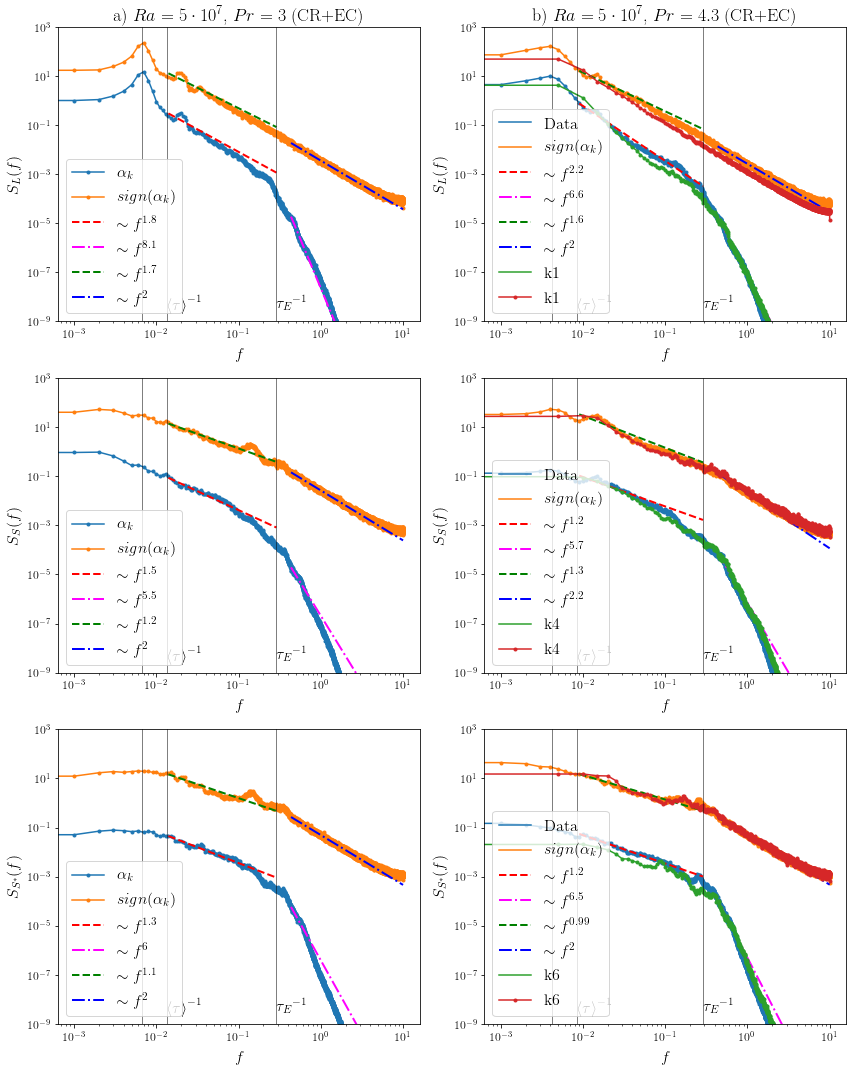

In [11]:
plt.rcParams['figure.figsize'] = (12.0, 15.0)

f, axes = plt.subplots(3, 2, sharey=False, sharex=False)
ax= np.ravel(axes)

for i, k in enumerate(['k1', 'k4', 'k6']):
    welch_pod_pr3.plot(x='f', y=k, loglog=True, ax=ax[i*2], marker='.')
    welch_sign_pr3.plot(x='f', y=k, loglog=True, ax=ax[i*2], marker='.')
    
    Alpha_pod_pr3.plot(x='f', y=k, loglog=True, ax=ax[i*2], linewidth=2.0, linestyle='--', color='red')    
    Gamma_pod_pr3.plot(x='f', y=k, loglog=True, ax=ax[i*2], linewidth=2.0, linestyle='-.', color='magenta')
    Alpha_sign_pr3.plot(x='f', y=k, loglog=True, ax=ax[i*2], linewidth=2.0, linestyle='--', color='green')
    Gamma_sign_pr3.plot(x='f', y=k, loglog=True, ax=ax[i*2], linewidth=2.0, linestyle='-.', color='blue')
    
    welch_pod_pr43.plot(x='f', y=k, loglog=True, ax=ax[i*2+1], marker='.')
    welch_sign_pr43.plot(x='f', y=k, loglog=True, ax=ax[i*2+1], marker='.')
    
    Alpha_pod_pr43.plot(x='f', y=k, loglog=True, ax=ax[i*2+1], linewidth=2.0, linestyle='--', color='red')    
    Gamma_pod_pr43.plot(x='f', y=k, loglog=True, ax=ax[i*2+1], linewidth=2.0, linestyle='-.', color='magenta')
    Alpha_sign_pr43.plot(x='f', y=k, loglog=True, ax=ax[i*2+1], linewidth=2.0, linestyle='--', color='green')
    Gamma_sign_pr43.plot(x='f', y=k, loglog=True, ax=ax[i*2+1], linewidth=2.0, linestyle='-.', color='blue')
    
    ax[i*2].legend(['$\\alpha_k$', '$sign(\\alpha_k)$',
                    "$\\sim f^{{ {0:2.2g} }}$".format(eval("alpha_pod_pr3."+k)), 
                    "$\\sim f^{{ {0:2.2g} }}$".format(eval("gamma_pod_pr3."+k)),
                    "$\\sim f^{{ {0:2.2g} }}$".format(eval("alpha_sign_pr3."+k)),
                    "$\\sim f^{{ {0:2.2g} }}$".format(eval("gamma_sign_pr3."+k)),])

    ax[i*2+1].legend(['Data', '$sign(\\alpha_k)$',
                      "$\\sim f^{{ {0:2.2g} }}$".format(eval("alpha_pod_pr43."+k)), 
                      "$\\sim f^{{ {0:2.2g} }}$".format(eval("gamma_pod_pr43."+k)),
                      "$\\sim f^{{ {0:2.2g} }}$".format(eval("alpha_sign_pr43."+k)),
                      "$\\sim f^{{ {0:2.2g} }}$".format(eval("gamma_sign_pr43."+k))])
    
    welch_pod_pr43_ra2e8.plot(x='f', y=k, loglog=True, ax=ax[i*2+1], marker='.')
    welch_sign_pr43_ra2e8.plot(x='f', y=k, loglog=True, ax=ax[i*2+1], marker='.')
    
labels=['L', 'L', 'S', 'S', 'S^*', 'S^*']
mean = [74.9, 119.2]
for i in range(0,6):
    ax[i].annotate('${\\tau_E}^{-1}$', (1/3.5,1e-9), xytext=(0,12), textcoords="offset points", xycoords='data', size='16')
    ax[i].annotate('${\langle\\tau\\rangle}^{-1}$', (1/mean[i%2],1e-9), xytext=(0,12), textcoords="offset points", xycoords='data', size='16')
    ax[i].axvline(x=1/3.5,   color='k', linewidth=0.5)
    #ax[i].axvline(x=1/50.0,   color='r', linestyle=':', linewidth=0.5)
    ax[i].axvline(x=1/mean[i%2],  color='k', linewidth=0.5)
    ax[i].axvline(x=0.5/mean[i%2], color='k', linewidth=0.5)
    ax[i].set_xlabel('$f$')
    ax[i].set_ylabel('$S_{{ {0:s} }}(f)$'.format(labels[i]))
    ax[i].set_ylim([1e-9,1e3])

ax[0].set_title('a) $Ra = 5\cdot10^7$, $Pr=3$ (CR+EC)', size=18)    
ax[1].set_title('b) $Ra = 5\cdot10^7$, $Pr=4.3$ (CR+EC)', size=18)    
    
plt.tight_layout()

### 3. Compute the distribution of waiting times
We focus on the range between the mean waiting time between successive flow reversals and the eddy turnover time and estimate the scaling exponent $P(\tau) \sim \tau^{-\beta}$

In [12]:
def crossings(x,y,z,c):
    x0 = pd.DataFrame() 
   
    n = y.shape[0]
    index = np.where((y[0:n-2]-c)*(y[1:n-1]-c) < 0)
    index = np.asarray(index)
    index = index.T[:,0]
    m = index.shape[0]
    
    x0['ti'] = x[index.T[0:m-1]]
    x0['tm'] = 0.5*(x[index.T[0:m-1]] + x[index.T[1:m]])
    x0['tf'] = x[index.T[1:m]]
    x0['tau'] = x0['tf'] - x0['ti']
    midpoint = (index.T[1:m]-index.T[0:m-1])/2 + index.T[0:m-1]    
    x0['tm'] = x[midpoint.astype(int)]    
    
    x0['idxi'] = index.T[0:m-1]
    x0['idxf'] = index.T[1:m]
    
    c = np.zeros((m-1,))    
    for n in range(0, m-1):
        a = np.max(z[np.arange(index.T[n],index.T[n+1])])
        b = np.min(z[np.arange(index.T[n],index.T[n+1])])
        c[n] = a if a>-b else b        
        
    x0['ymax'] = c
    return x0, index.T;

In [13]:
zero_pod_pr3 = exponents()
zero_pod_pr43 = exponents()

tau_pod_pr3 = exponents()
tau_pod_pr43 = exponents()

zero_pod_pr3_ra1e7 = exponents()
tau_pod_pr3_ra1e7 = exponents()

zero_pod_pr43_ra2e8 = exponents()
tau_pod_pr43_ra2e8 = exponents()


hbins = np.logspace(0.0,3.0,100)


for k in ['k1', 'k2', 'k3', 'k4', 'k5', 'k6']:    
    cross, _ = np.array(crossings(pod_pr3.t.values, pod_pr3[k].values, pod_pr3[k].values,0.))
    setattr(zero_pod_pr3, k, cross)
    
    h = np.histogram(eval('zero_pod_pr3.'+k+'.tau'), hbins, density=True)
    binc = 0.5*(h[1][1:]+h[1][:-1])
    bins = np.where(np.logical_and(binc > 3.5, binc < 75.0))
    setattr(tau_pod_pr3, k, h)
    setattr(tau_pod_pr3, 'binc', binc)
    setattr(tau_pod_pr3, 'bins', bins)
    
    cross, _ = np.array(crossings(pod_pr43.t.values, pod_pr43[k].values, pod_pr43[k].values,0.))
    setattr(zero_pod_pr43, k, cross)
    
    h = np.histogram(eval('zero_pod_pr43.'+k+'.tau'), hbins, density=True)
    binc = 0.5*(h[1][1:]+h[1][:-1])
    bins = np.where(np.logical_and(binc > 3.5, binc < 120.0))
    setattr(tau_pod_pr43, k, h)
    setattr(tau_pod_pr43, 'binc', binc)
    setattr(tau_pod_pr43, 'bins', bins)

    
    cross, _ = np.array(crossings(pod_pr3_ra1e7.t.values, pod_pr3_ra1e7[k].values, pod_pr3_ra1e7[k].values,0.))
    setattr(zero_pod_pr3_ra1e7, k, cross)
    
    h = np.histogram(eval('zero_pod_pr3_ra1e7.'+k+'.tau'), hbins, density=True)
    binc = 0.5*(h[1][1:]+h[1][:-1])
    bins = np.where(np.logical_and(binc > 3.5, binc < 75.0))
    setattr(tau_pod_pr3_ra1e7, k, h)
    setattr(tau_pod_pr3_ra1e7, 'binc', binc)
    setattr(tau_pod_pr3_ra1e7, 'bins', bins)
    
    
    cross, _ = np.array(crossings(pod_pr43_ra2e8.t.values, pod_pr43_ra2e8[k].values, pod_pr43_ra2e8[k].values,0.))
    setattr(zero_pod_pr43_ra2e8, k, cross)
    
    h = np.histogram(eval('zero_pod_pr43_ra2e8.'+k+'.tau'), hbins, density=True)
    binc = 0.5*(h[1][1:]+h[1][:-1])
    bins = np.where(np.logical_and(binc > 3.5, binc < 75.0))
    setattr(tau_pod_pr43_ra2e8, k, h)
    setattr(tau_pod_pr43_ra2e8, 'binc', binc)
    setattr(tau_pod_pr43_ra2e8, 'bins', bins)    
    

/home/andres/miniconda3/envs/housecleaning_ac/lib/python3.7/site-packages/scipy/optimize/minpack.py:794: OptimizeWarning: Covariance of the parameters could not be estimated
  category=OptimizeWarning)


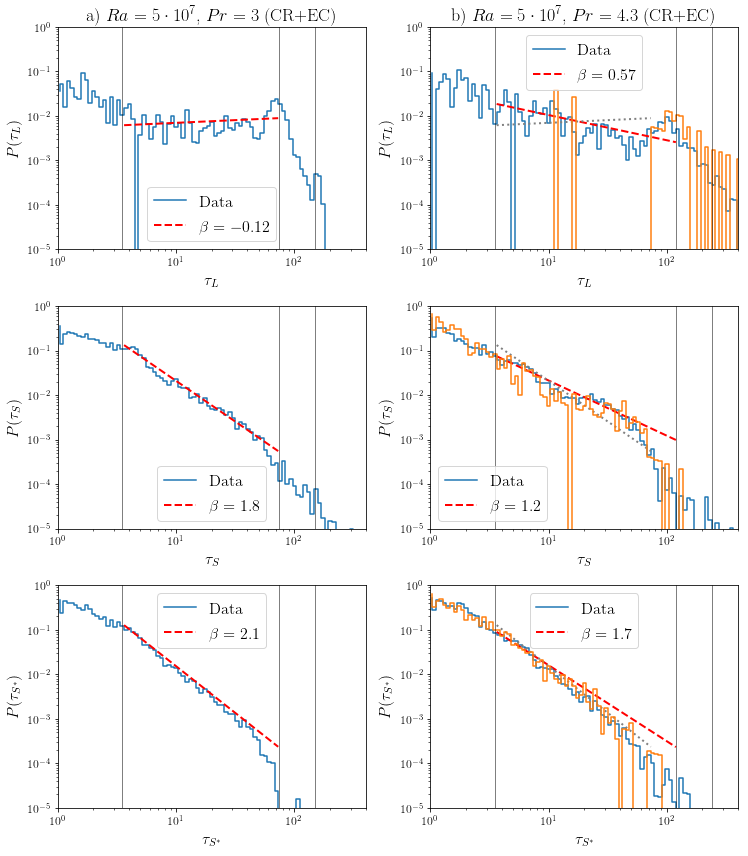

In [14]:
def func2(x, a, b, c):
    return a * np.power(x, -b) 


beta_pod_pr3 = exponents()
beta_pod_pr43 = exponents()

plt.rcParams['figure.figsize'] = (10.5, 12.0)

f, axes = plt.subplots(3, 2, sharey=False, sharex=False)
ax= np.ravel(axes)

for i, k in enumerate(['k1', 'k4', 'k6']):
    popt, pcov = curve_fit(func2, tau_pod_pr3.binc[tau_pod_pr3.bins], eval('tau_pod_pr3.'+k+'[0][tau_pod_pr3.bins]'))    
    setattr(beta_pod_pr3, k, popt[1])
    
    ax[i*2].step(tau_pod_pr3.binc, eval('tau_pod_pr3.'+k+'[0]'))
    ax[i*2].plot(tau_pod_pr3.binc[tau_pod_pr3.bins], 
                 func2(tau_pod_pr3.binc[tau_pod_pr3.bins], popt[0], popt[1], popt[2]), 
                 color='red', linestyle='--', linewidth=2.0)

    popt2, pcov2 = curve_fit(func2, tau_pod_pr43.binc[tau_pod_pr43.bins], eval('tau_pod_pr43.'+k+'[0][tau_pod_pr43.bins]'))    
    setattr(beta_pod_pr43, k, popt2[1])    
    ax[i*2+1].step(tau_pod_pr43.binc, eval('tau_pod_pr43.'+k+'[0]'))
    ax[i*2+1].plot(tau_pod_pr43.binc[tau_pod_pr43.bins],func2(tau_pod_pr43.binc[tau_pod_pr43.bins], popt2[0], popt2[1], popt2[2]), color='red', linestyle='--', linewidth=2.0)
   

    ax[i*2].legend(['Data', 
                  "$\\beta={{ {0:2.2g} }}$".format(eval("beta_pod_pr3."+k))])
    ax[i*2+1].legend(['Data', 
                  "$\\beta={{ {0:2.2g} }}$".format(eval("beta_pod_pr43."+k))])

    ax[i*2+1].plot(tau_pod_pr3.binc[tau_pod_pr3.bins], func2(tau_pod_pr3.binc[tau_pod_pr3.bins], popt[0], popt[1], popt[2]), 
                 color='grey', linestyle=':', linewidth=2.0)
    
    
    ax[i*2+1].step(tau_pod_pr43_ra2e8.binc, eval('tau_pod_pr43_ra2e8.'+k+'[0]'))

labels=['L', 'L', 'S', 'S', 'S^*', 'S^*']
mean = [74.9, 119.2]
for i in range(0,6):
    ax[i].set_xscale('log')
    ax[i].set_yscale('log')
    ax[i].set_ylim([1e-5,1e0])
    ax[i].set_xlim([1,400])

    #ax[i].annotate('${\\tau_E}$', (3.5,1e-4), xytext=(0,-12), textcoords="offset points", xycoords='data', size='16')
    #ax[i].annotate('${\langle\\tau\\rangle}$', (mean[i%2],1e-4), xytext=(0,-12), textcoords="offset points", xycoords='data', size='16')
    ax[i].axvline(x=3.5,   color='k', linewidth=0.5)
    ax[i].axvline(x=mean[i%2],  color='k', linewidth=0.5)
    ax[i].axvline(x=2*mean[i%2], color='k', linewidth=0.5)

    ax[i].set_ylabel('$P(\\tau_{{ {0:s} }})$'.format(labels[i]))
    ax[i].set_xlabel('$\\tau_{{ {0:s} }}$'.format(labels[i]))
    

ax[0].set_title('a) $Ra = 5\cdot10^7$, $Pr=3$ (CR+EC)', size=18)    
ax[1].set_title('b) $Ra = 5\cdot10^7$, $Pr=4.3$ (CR+EC)', size=18)    
    
plt.tight_layout()

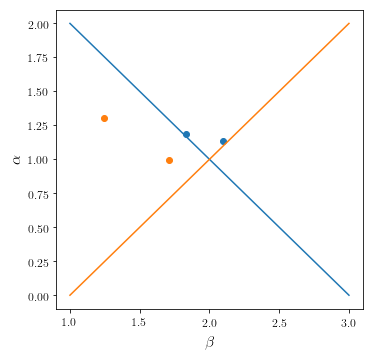

In [15]:
plt.rcParams['figure.figsize'] = (5.5, 5.5)

plt.scatter([beta_pod_pr3.k4, beta_pod_pr3.k6], 
            [alpha_sign_pr3.k4, alpha_sign_pr3.k6])

plt.scatter([beta_pod_pr43.k4, beta_pod_pr43.k6], 
            [alpha_sign_pr43.k4, alpha_sign_pr43.k6])

plt.plot(np.arange(1,4), 3-np.arange(1,4))
plt.plot(np.arange(1,4), np.arange(1,4) - 1)


plt.xlabel('$ \\beta $ ')
plt.ylabel('$ \\alpha$ ')

plt.show()